In [13]:
import directional_tile_codes as dtc

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Veryfing Construction

### Construct a Directional Word

In [15]:
def direction_string(word):
    return "".join(direction.name for direction in word.word)

def edge_record(edge):
    return {
        "origin": (edge.origin.x, edge.origin.y),
        "orientation": edge.orientation.name,
        "middle": (edge.middle.x, edge.middle.y),
    }

In [ ]:
word = dtc.DirectionalWord("NNESENN")

assert direction_string(word) == "NNESENN"
assert word.weight == 7
assert word.B == 3

x_word_edges = word.get_x_edges()
z_word_edges = word.get_z_edges()

assert len(x_word_edges) == 7
assert len(z_word_edges) == 7
assert len(set(x_word_edges)) == 7
assert len(set(z_word_edges)) == 7

print("word =", direction_string(word))
print("weight =", word.weight)
print("B =", word.B)
print("inverse word =", direction_string(word.inverse()))

word = NNEESEENN
weight = 9
B = 5
inverse word = SSWWNWWSS


In [17]:
print("Ordered X-string edges:")
display(pd.DataFrame(edge_record(e) for e in x_word_edges))

print("Ordered Z-string edges:")
display(pd.DataFrame(edge_record(e) for e in z_word_edges))

Ordered X-string edges:


,origin,orientation,middle
0,"(0, 0)",VERTICAL,"(0, 1)"
1,"(0, 2)",VERTICAL,"(0, 3)"
2,"(0, 4)",HORIZONTAL,"(1, 4)"
3,"(2, 4)",HORIZONTAL,"(3, 4)"
4,"(4, 2)",VERTICAL,"(4, 3)"
5,"(4, 2)",HORIZONTAL,"(5, 2)"
6,"(6, 2)",HORIZONTAL,"(7, 2)"
7,"(8, 2)",VERTICAL,"(8, 3)"
8,"(8, 4)",VERTICAL,"(8, 5)"


Ordered Z-string edges:


,origin,orientation,middle
0,"(0, 0)",HORIZONTAL,"(1, 0)"
1,"(0, 2)",HORIZONTAL,"(1, 2)"
2,"(2, 2)",VERTICAL,"(2, 3)"
3,"(4, 2)",VERTICAL,"(4, 3)"
4,"(4, 2)",HORIZONTAL,"(5, 2)"
5,"(6, 0)",VERTICAL,"(6, 1)"
6,"(8, 0)",VERTICAL,"(8, 1)"
7,"(8, 2)",HORIZONTAL,"(9, 2)"
8,"(8, 4)",HORIZONTAL,"(9, 4)"


### Construct a Tile

In [18]:
x_tile = dtc.Tile(dtc.TileType.X, word)
z_tile = dtc.Tile(dtc.TileType.Z, word)

print("X fits box:", x_tile.fits_box())
print("Z fits box:", z_tile.fits_box())
print("Mutuality:", dtc.Tile.check_mutuality(x_tile, z_tile))
print("Ordered parity condition:", dtc.Tile.check_parity(x_tile))
print("Complete tile check:", dtc.Tile.check(x_tile, z_tile))

assert x_tile.B == 3
assert z_tile.B == 3
assert x_tile.fits_box()
assert z_tile.fits_box()
assert dtc.Tile.check_mutuality(x_tile, z_tile)
assert dtc.Tile.check_parity(x_tile)
assert dtc.Tile.check(x_tile, z_tile)
print("\nAll tile-validity tests passed :)")


X fits box: True
Z fits box: True
Mutuality: True
Ordered parity condition: True
Complete tile check: True


AssertionError: 

In [ ]:
print("X tile support")
display(pd.DataFrame(edge_record(e) for e in x_tile.get_edges()))

print("Z tile support (after translation onto the mutual tile)")
display(pd.DataFrame(edge_record(e) for e in z_tile.get_edges()))

X tile support


,origin,orientation,middle
0,"(0, 0)",VERTICAL,"(0, 1)"
1,"(0, 2)",VERTICAL,"(0, 3)"
2,"(0, 4)",HORIZONTAL,"(1, 4)"
3,"(2, 2)",VERTICAL,"(2, 3)"
4,"(2, 2)",HORIZONTAL,"(3, 2)"
5,"(4, 2)",VERTICAL,"(4, 3)"
6,"(4, 4)",VERTICAL,"(4, 5)"


Z tile support (after translation onto the mutual tile)


,origin,orientation,middle
0,"(0, 0)",HORIZONTAL,"(1, 0)"
1,"(0, 2)",HORIZONTAL,"(1, 2)"
2,"(2, 2)",VERTICAL,"(2, 3)"
3,"(2, 2)",HORIZONTAL,"(3, 2)"
4,"(4, 0)",VERTICAL,"(4, 1)"
5,"(4, 2)",HORIZONTAL,"(5, 2)"
6,"(4, 4)",HORIZONTAL,"(5, 4)"


### Construct Directional Tile Code

layout edges:           72
X checks before prune:  32
Z checks before prune:  32
data after prune:       60
X checks after prune:   28
Z checks after prune:   28


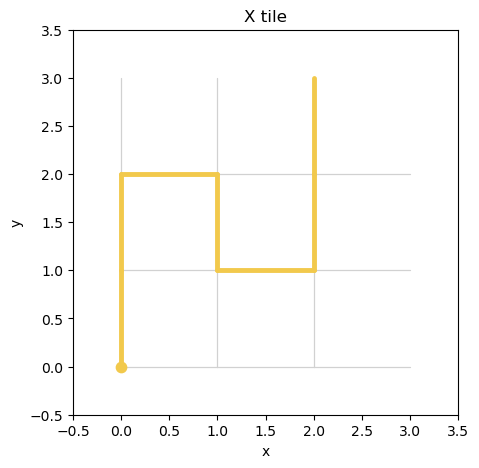

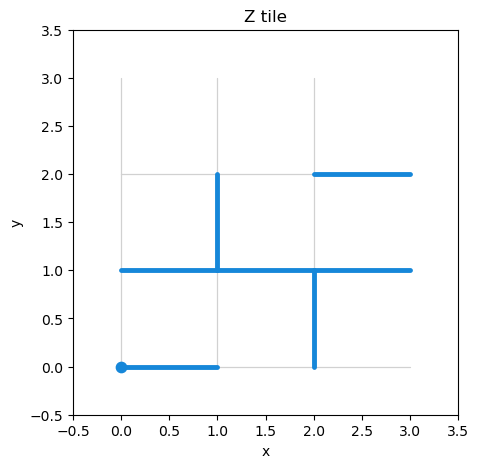

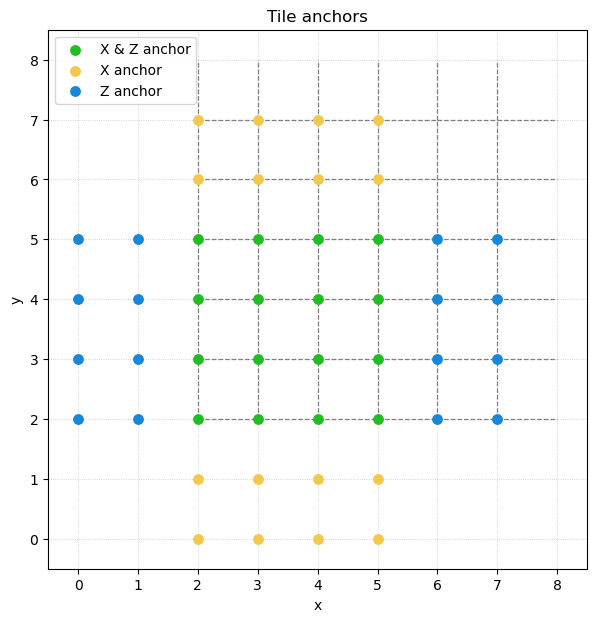

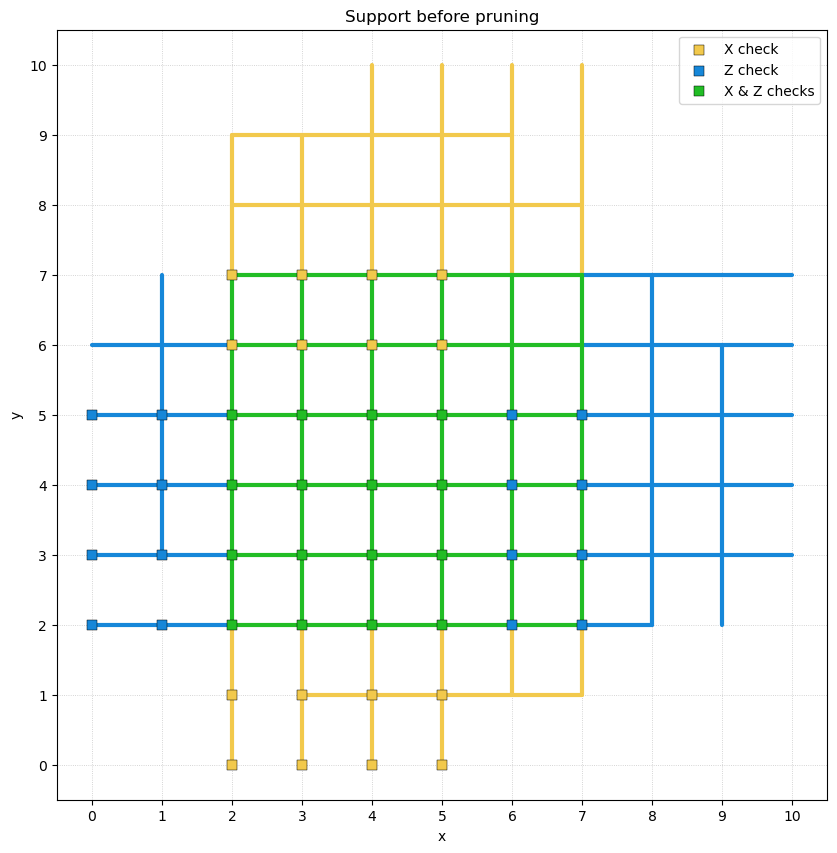

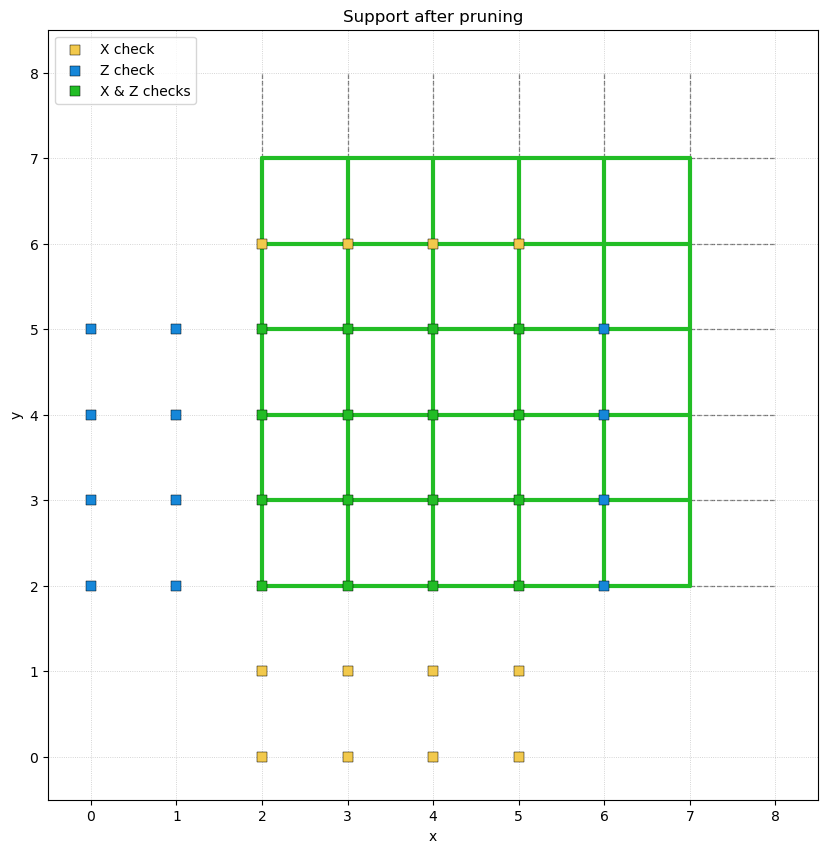

In [ ]:
word = dtc.DirectionalWord("NNESENN")
code = dtc.DirTileCode(M=4, N=4, word=word)

dtc.print_visualization_summary(code)

dtc.plot_x_tile(code)
plt.show()

dtc.plot_z_tile(code)
plt.show()

dtc.plot_anchors(code)
plt.show()

dtc.plot_support_before_prune(code)
plt.show()

dtc.plot_support_after_prune(code)
plt.show()